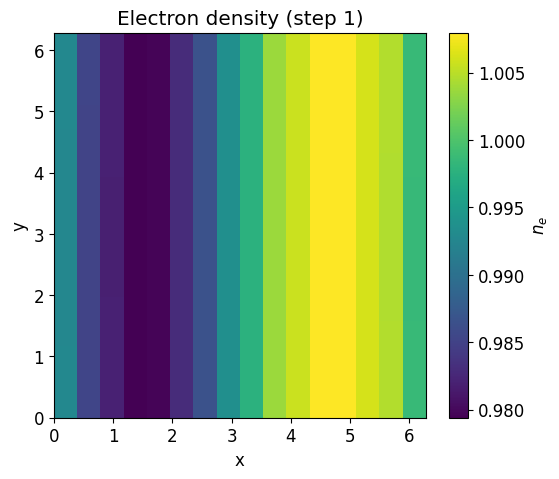

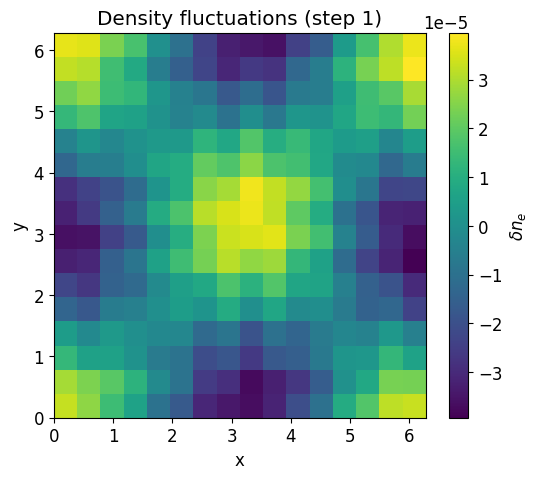

Field shape: (16, 16, 1)


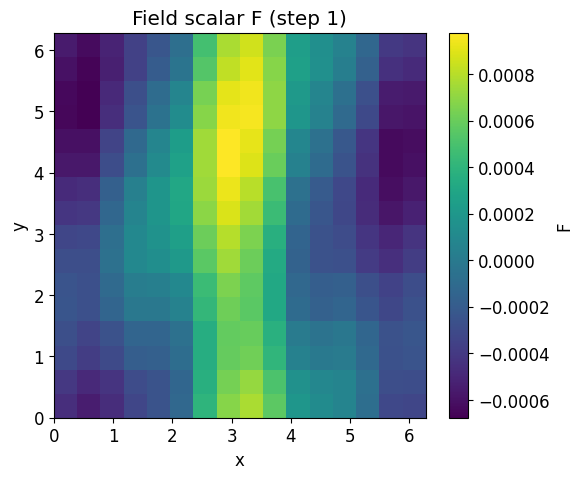

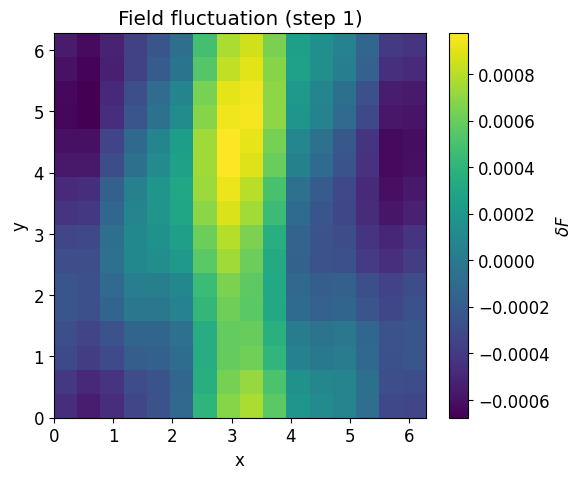

M1 shape: (16, 16, 1)


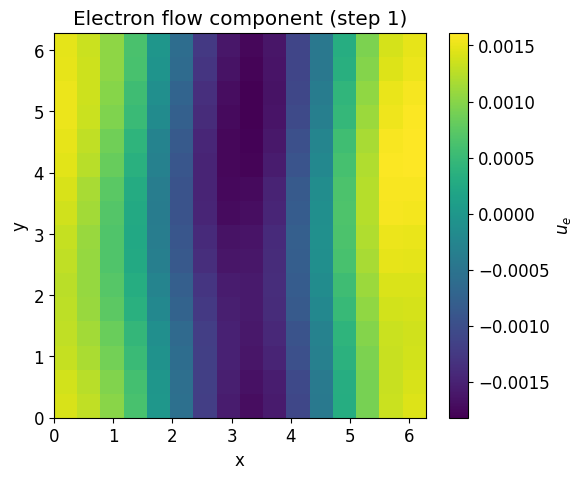

ValueError: x and y must have same first dimension, but have shapes (17,) and (16,)

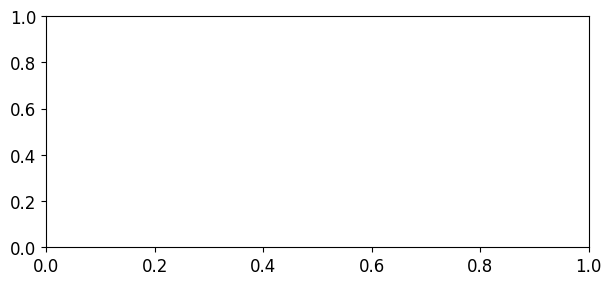

In [2]:
# =========================
# ROBUST REDUCED POSTGKYL ANALYSIS
# =========================

import postgkyl as pg
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (6,5)
plt.rcParams["font.size"] = 12

# -------------------------
# USER SETTINGS
# -------------------------
basedir = "/dartfs-hpc/rc/home/7/f006xp7/gkeyll_tests/weibel_2x2v"
step = 1
polyOrder = 1
basis = "ms"

# -------------------------
# HELPERS
# -------------------------
def load_interp(path):
    gd = pg.data.GData(path)
    gi = pg.data.GInterpModal(gd, polyOrder, basis)
    grid, vals = gi.interpolate()
    return grid, vals

def pcolor(x, y, A, title, label):
    plt.figure()
    plt.pcolormesh(x, y, A.T, shading="auto")
    plt.colorbar(label=label)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.show()

# =========================
# ELECTRON DENSITY (M0)
# =========================
grid_n, ne = load_interp(f"{basedir}/drift_wave_instability-elc_M0_{step}.gkyl")
x, y = grid_n[0], grid_n[1]

ne2d = ne[:, :, 0]
dne = ne2d - ne2d.mean(axis=1, keepdims=True)

pcolor(x, y, ne2d, f"Electron density (step {step})", r"$n_e$")
pcolor(x, y, dne,  f"Density fluctuations (step {step})", r"$\delta n_e$")

# =========================
# FIELD (REDUCED SCALAR)
# =========================
grid_f, fld = load_interp(f"{basedir}/drift_wave_instability-field_{step}.gkyl")
x_f, y_f = grid_f[0], grid_f[1]

print("Field shape:", fld.shape)

F = fld[:, :, 0]
dF = F - np.mean(F)

pcolor(x_f, y_f, F,  f"Field scalar F (step {step})", "F")
pcolor(x_f, y_f, dF, f"Field fluctuation (step {step})", r"$\delta F$")

# =========================
# ELECTRON FLOW (M1)
# =========================
grid_m1, m1 = load_interp(f"{basedir}/drift_wave_instability-elc_M1_{step}.gkyl")
print("M1 shape:", m1.shape)

# Only ONE momentum component exists
n_u = m1[:, :, 0]
u = n_u / (ne2d + 1e-30)

pcolor(x, y, u, f"Electron flow component (step {step})", r"$u_e$")

# =========================
# CROSS-PHASE CHECK
# =========================
ix = len(x)//2

plt.figure(figsize=(7,3))
plt.plot(y, dne[ix, :], label=r"$\delta n_e$")
plt.plot(y_f, dF[ix, :], label=r"$\delta F$")
plt.xlabel("y")
plt.legend()
plt.title("Mid-x cross-phase: density vs field")
plt.show()
